# Data Science Examination 
Student Number 

In [15]:
# Imports 
import urllib.request
import urllib.error
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
%matplotlib inline


## Task 1: Initial Data Preparation

In [5]:
# downloading the File
url = "http://mlg.ucd.ie/modules/python/bills.csv"

try:
    response = urllib.request.urlopen(url)
    raw_csv = response.read().decode("utf-8")
    df = pd.read_csv(StringIO(raw_csv)) # makes it a dummy file 
    
except urllib.error.HTTPError as e:
    print(f"HTTP Error {e.code}: Could not download CSV file")
except urllib.error.URLError as e:
    print(f"Network Error: {e.reason}")
except Exception as e:
    print(f"Unexpected error: {e}")

df.head()

,floor_area,energy_rating,num_occupants,electric_heating,property_type,num_bedrooms,house_age,energy_plan,monthly_bill
0,1227,7.0,2,0,semi_detached,3,33,gas,78.43
1,1557,10.0,5,1,semi_detached,4,64,dual,129.11
2,2292,8.0,8,0,detached,5,55,dual,153.61
3,2149,7.0,8,0,detached,5,40,dual,104.98
4,1603,11.0,5,0,semi_detached,4,113,electricity,125.07


In [6]:
df.isna().sum()

floor_area           0
energy_rating       21
num_occupants        0
electric_heating     0
property_type        0
num_bedrooms         0
house_age            0
energy_plan          0
monthly_bill         0
dtype: int64

In [10]:
#df.groupby("energy_plan")["energy_rating"].agg('mean', 'median', 'mode')
df.groupby("energy_plan")["energy_rating"].agg(['mean', 'median'])

,mean,median
energy_plan,,
dual,8.472693,9.0
electricity,8.704478,9.0
gas,9.044728,9.0


In [12]:
df["energy_rating"].median()

np.float64(9.0)

In [13]:
df["energy_rating"].fillna(df["energy_rating"].median()) 

0        7.0
1       10.0
2        8.0
3        7.0
4       11.0
        ... 
1195    13.0
1196    10.0
1197    12.0
1198    10.0
1199    14.0
Name: energy_rating, Length: 1200, dtype: float64

Text(0, 0.5, 'Frequency')

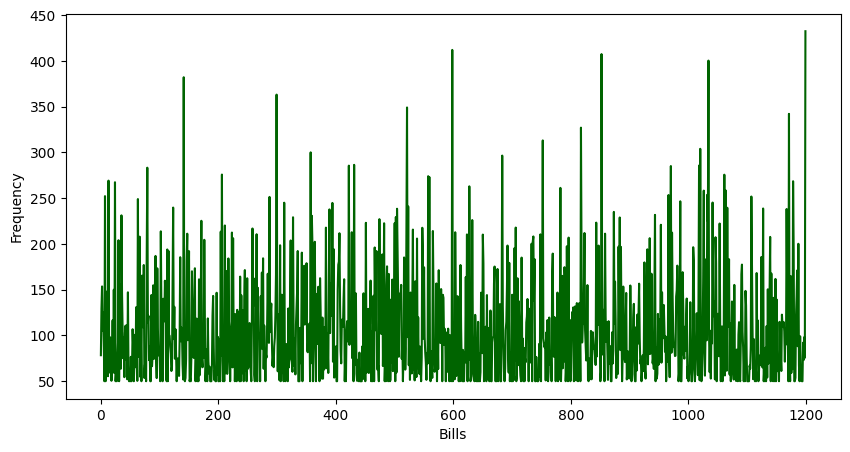

In [18]:
ax = df["monthly_bill"].plot(figsize=(10, 5), color="darkgreen")
ax.set_xlabel("Bills"); ax.set_ylabel("Frequency")

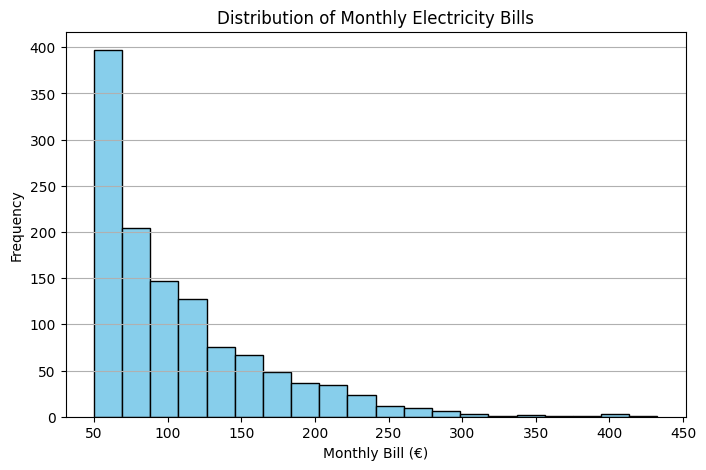

In [31]:
plt.figure(figsize=(8,5))

plt.hist(
    df["monthly_bill"],
    bins=20,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Monthly Electricity Bills")
plt.xlabel("Monthly Bill (€)")
plt.ylabel("Frequency")

plt.grid(axis="y")

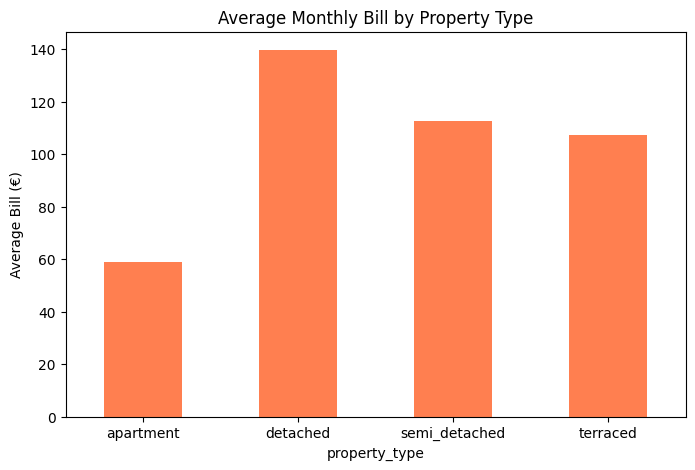

In [37]:
df.groupby("property_type")["monthly_bill"].mean().plot(
    kind="bar",
    figsize=(8,5),
    color="coral"
)

plt.title("Average Monthly Bill by Property Type")
plt.ylabel("Average Bill (€)")
plt.xticks(rotation =0)
plt.show()

In [30]:
# numeric correlation matrix
correlations = df.corr(numeric_only=True)

# correlations with monthly bill
correlations["monthly_bill"].sort_values(ascending=False)

monthly_bill        1.000000
energy_rating       0.583921
num_bedrooms        0.544161
num_occupants       0.541804
floor_area          0.519953
house_age           0.405423
electric_heating    0.166792
Name: monthly_bill, dtype: float64

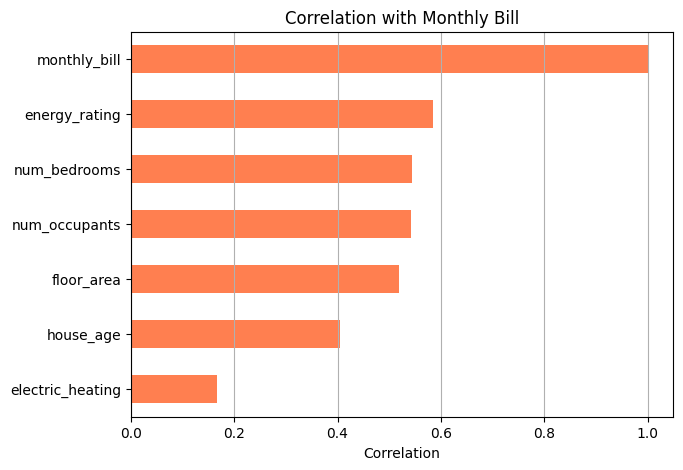

In [33]:
correlations["monthly_bill"].sort_values().plot(
    kind='barh',
    figsize=(7,5),
    color='coral'
)

plt.title("Correlation with Monthly Bill")
plt.xlabel("Correlation")
plt.grid(axis='x')


In [ ]:
# select numeric columns only
numeric_df = df.select_dtypes(include='number')

# input features
X = numeric_df.drop("monthly_bill", axis=1)

# target variable
y = numeric_df["monthly_bill"]